# Evaluation result for RF

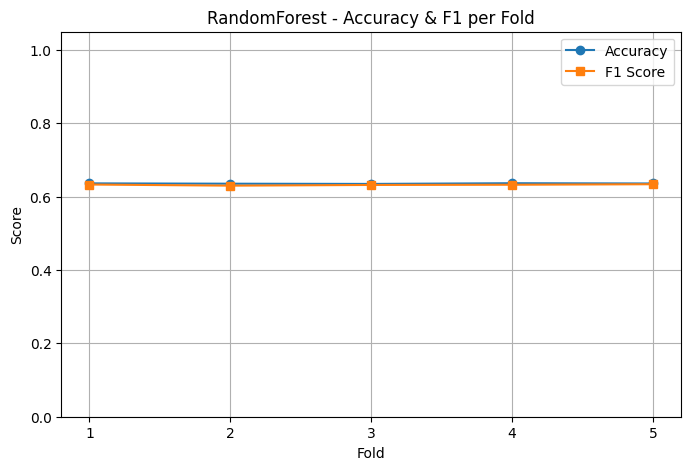

In [7]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay

# Path to saved metrics JSON
json_path = r"E:\Thesis\llm-ids-shield\Notebooks\results\rf_metrics.json"
 

with open(json_path, "r") as f:
    metrics_all = json.load(f)

# Check structure
list(metrics_all.keys())

model_name = "RandomForest"  # replace as needed
folds = metrics_all[model_name]

# Extract metrics
accuracy = [fold['accuracy'] for fold in folds]
f1_score_vals = [fold['f1'] for fold in folds]

# Plot Accuracy
plt.figure(figsize=(8,5))
plt.plot(range(1, len(accuracy)+1), accuracy, marker='o', label='Accuracy')
plt.plot(range(1, len(f1_score_vals)+1), f1_score_vals, marker='s', label='F1 Score')
plt.title(f'{model_name} - Accuracy & F1 per Fold')
plt.xlabel('Fold')
plt.ylabel('Score')
plt.ylim(0,1.05)
plt.xticks(range(1, len(accuracy)+1))
plt.grid(True)
plt.legend()
plt.show()


In [8]:
avg_accuracy = np.mean([fold['accuracy'] for fold in folds])
avg_f1 = np.mean([fold['f1'] for fold in folds])
avg_precision = np.mean([fold['precision'] for fold in folds])
avg_recall = np.mean([fold['recall'] for fold in folds])
avg_roc_auc = np.mean([fold['roc_auc'] for fold in folds if fold['roc_auc'] is not None])

print(f"{model_name} - Average Metrics Across {len(folds)} Folds")
print(f"Accuracy: {avg_accuracy:.4f}")
print(f"F1 Score: {avg_f1:.4f}")
print(f"Precision: {avg_precision:.4f}")
print(f"Recall: {avg_recall:.4f}")
print(f"ROC AUC: {avg_roc_auc:.4f}")


RandomForest - Average Metrics Across 5 Folds
Accuracy: 0.6359
F1 Score: 0.6325
Precision: 0.6387
Recall: 0.6359
ROC AUC: 0.9318


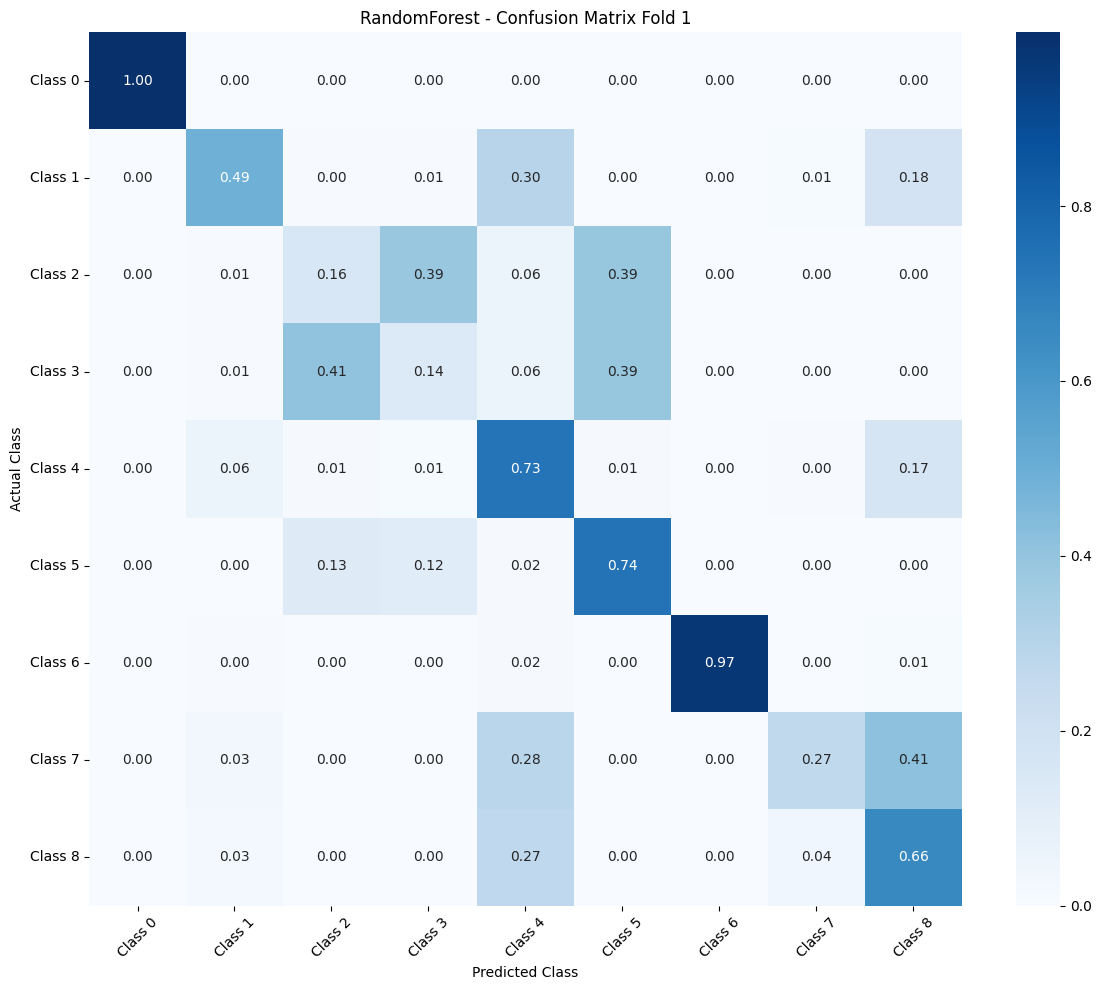

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_confusion_matrix(cm, class_names=None, fold_num=1, model_name="Model", normalize=True):
    """
    cm: confusion matrix (numpy array)
    class_names: list of class labels
    fold_num: fold number for title
    model_name: name of the model
    normalize: whether to normalize by row (per-class)
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(12,10))
    sns.heatmap(cm, annot=True, fmt=".2f" if normalize else "d", cmap="Blues", cbar=True,
                xticklabels=class_names, yticklabels=class_names)
    
    plt.title(f"{model_name} - Confusion Matrix Fold {fold_num}")
    plt.ylabel("Actual Class")
    plt.xlabel("Predicted Class")
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
# Example usage:
fold_num = 1
cm = np.array(metrics_all['RandomForest'][fold_num-1]['confusion_matrix'])
class_names = [f"Class {i}" for i in range(9)]  # replace with your actual class names if you have
plot_confusion_matrix(cm, class_names=class_names, fold_num=fold_num, model_name="RandomForest")




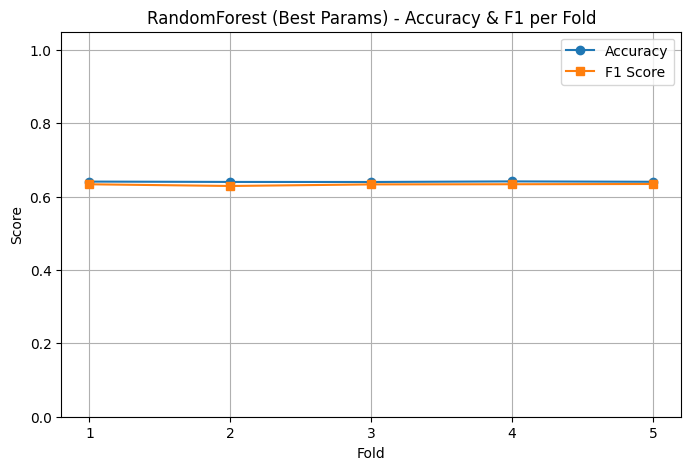

In [10]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay

# ---- Load Metrics ----
json_path = r"E:\Thesis\llm-ids-shield\Notebooks\results\rf_best_metrics.json"  # updated file

with open(json_path, "r") as f:
    metrics_all = json.load(f)

# There is only one model in this metrics file → get the name dynamically
model_name = list(metrics_all.keys())[0]
folds = metrics_all[model_name]

# ---- Extract Metrics ----
accuracy = [fold['accuracy'] for fold in folds]
f1_score_vals = [fold['f1'] for fold in folds]

# ---- Plot Accuracy & F1 ----
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(accuracy) + 1), accuracy, marker='o', label='Accuracy')
plt.plot(range(1, len(f1_score_vals) + 1), f1_score_vals, marker='s', label='F1 Score')

plt.title(f'{model_name} (Best Params) - Accuracy & F1 per Fold')
plt.xlabel('Fold')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.xticks(range(1, len(accuracy) + 1))
plt.grid(True)
plt.legend()
plt.show()


In [11]:
avg_accuracy = np.mean([fold['accuracy'] for fold in folds])
avg_f1 = np.mean([fold['f1'] for fold in folds])
avg_precision = np.mean([fold['precision'] for fold in folds])
avg_recall = np.mean([fold['recall'] for fold in folds])
avg_roc_auc = np.mean([fold['roc_auc'] for fold in folds if fold['roc_auc'] is not None])

print(f"{model_name} - Average Metrics Across {len(folds)} Folds")
print(f"Accuracy: {avg_accuracy:.4f}")
print(f"F1 Score: {avg_f1:.4f}")
print(f"Precision: {avg_precision:.4f}")
print(f"Recall: {avg_recall:.4f}")
print(f"ROC AUC: {avg_roc_auc:.4f}")


RandomForest - Average Metrics Across 5 Folds
Accuracy: 0.6409
F1 Score: 0.6331
Precision: 0.6451
Recall: 0.6409
ROC AUC: 0.9428


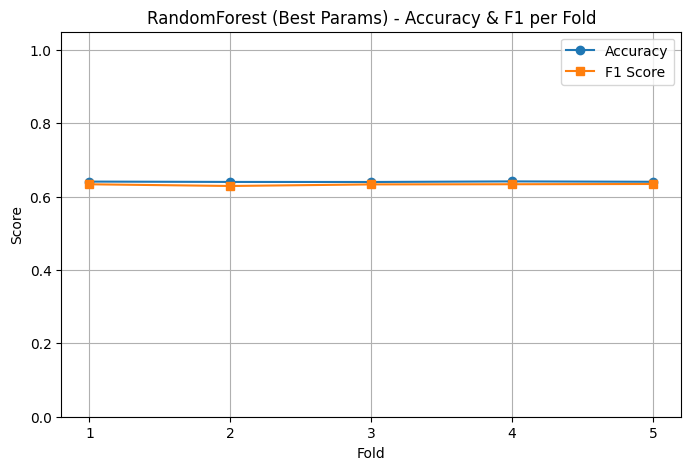


===== METRICS SUMMARY TABLE =====
   Fold  Accuracy  Precision    Recall  F1 Score
0     1  0.641283   0.645841  0.641283  0.633927
1     2  0.640324   0.637711  0.640324  0.629291
2     3  0.640180   0.647428  0.640180  0.633589
3     4  0.641799   0.645986  0.641799  0.634054
4     5  0.640744   0.648421  0.640744  0.634722

AVERAGES:
Fold         3.000000
Accuracy     0.640866
Precision    0.645077
Recall       0.640866
F1 Score     0.633117
dtype: float64


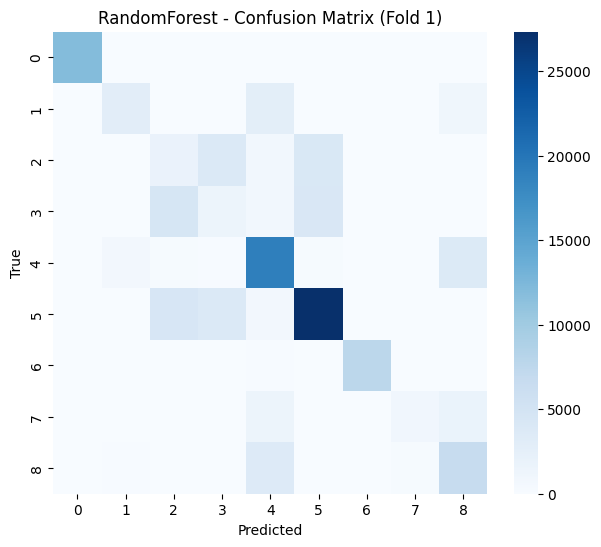

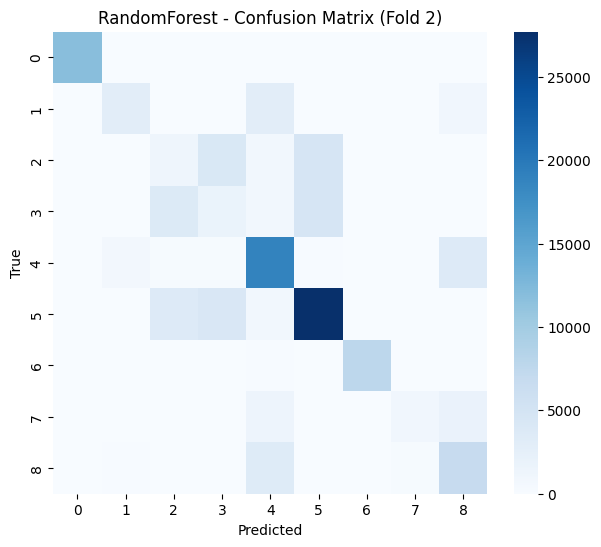

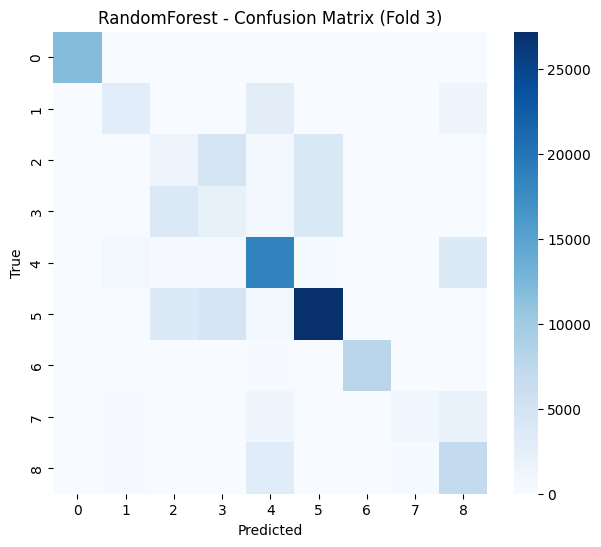

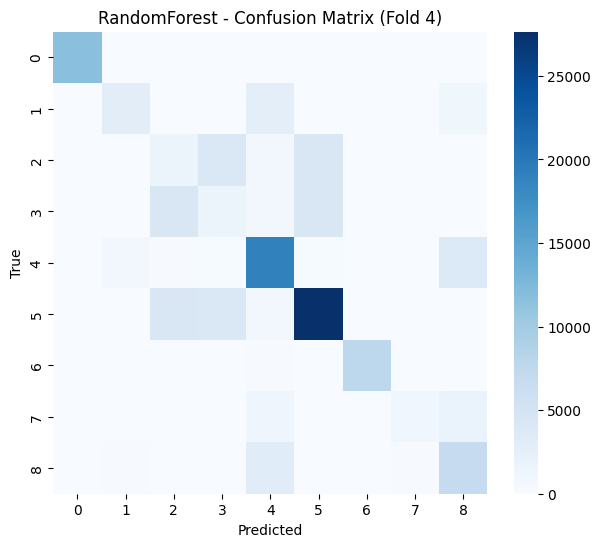

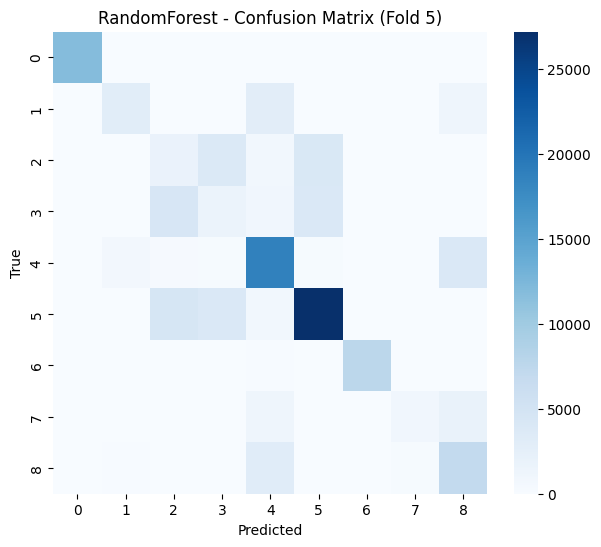

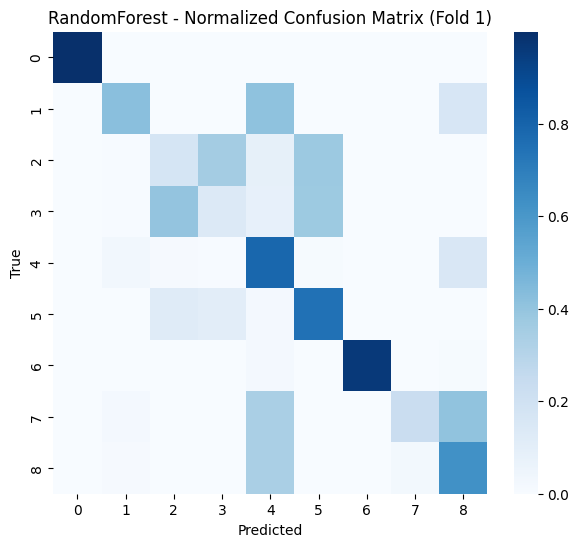

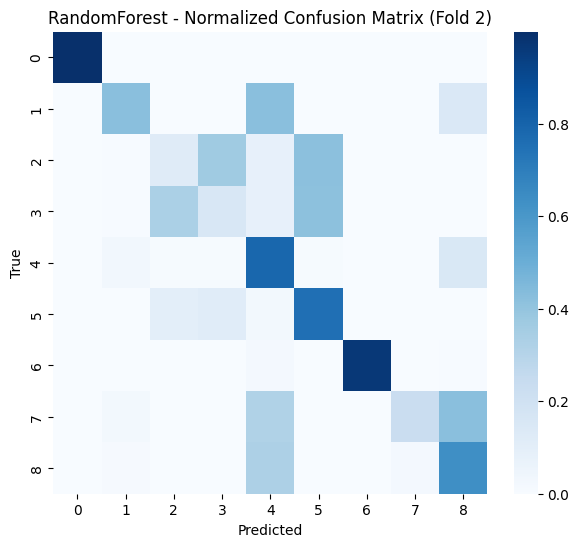

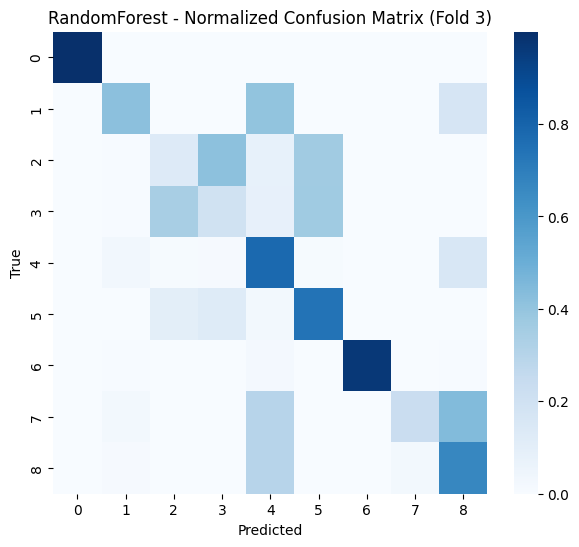

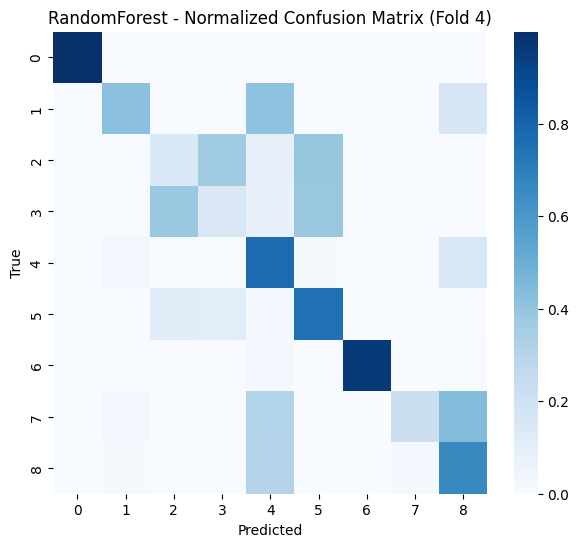

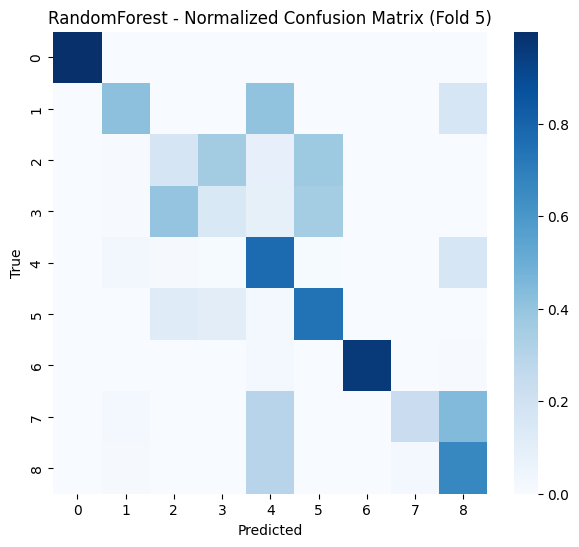

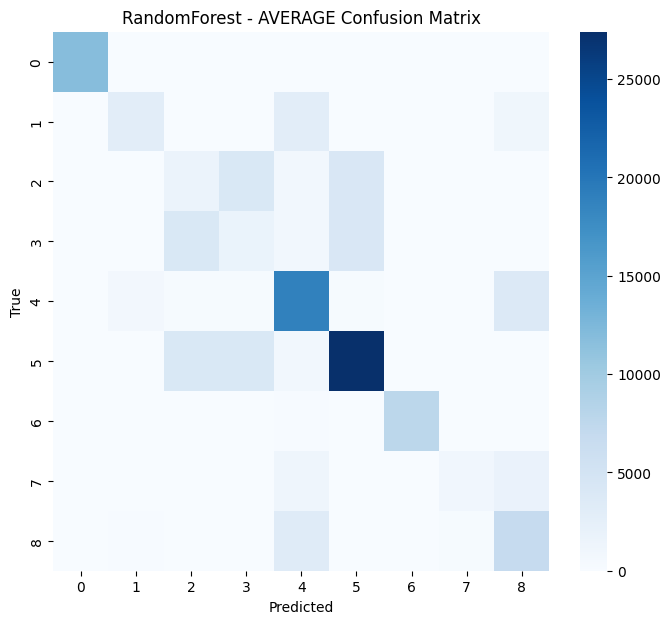

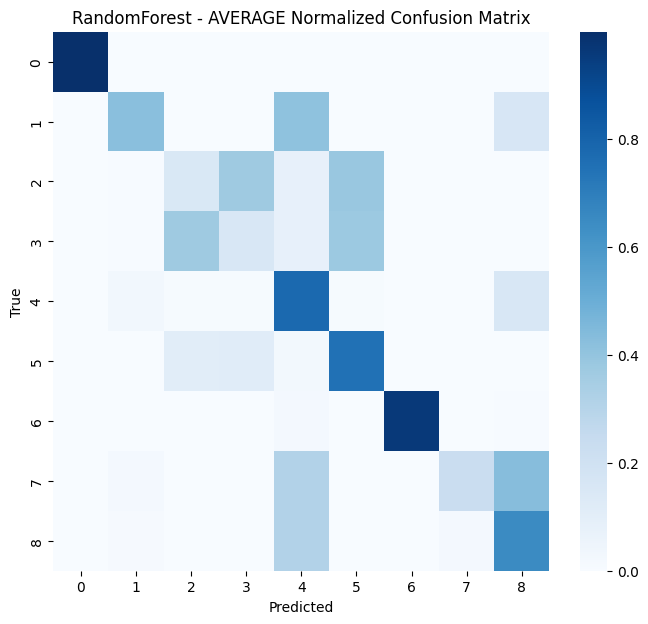

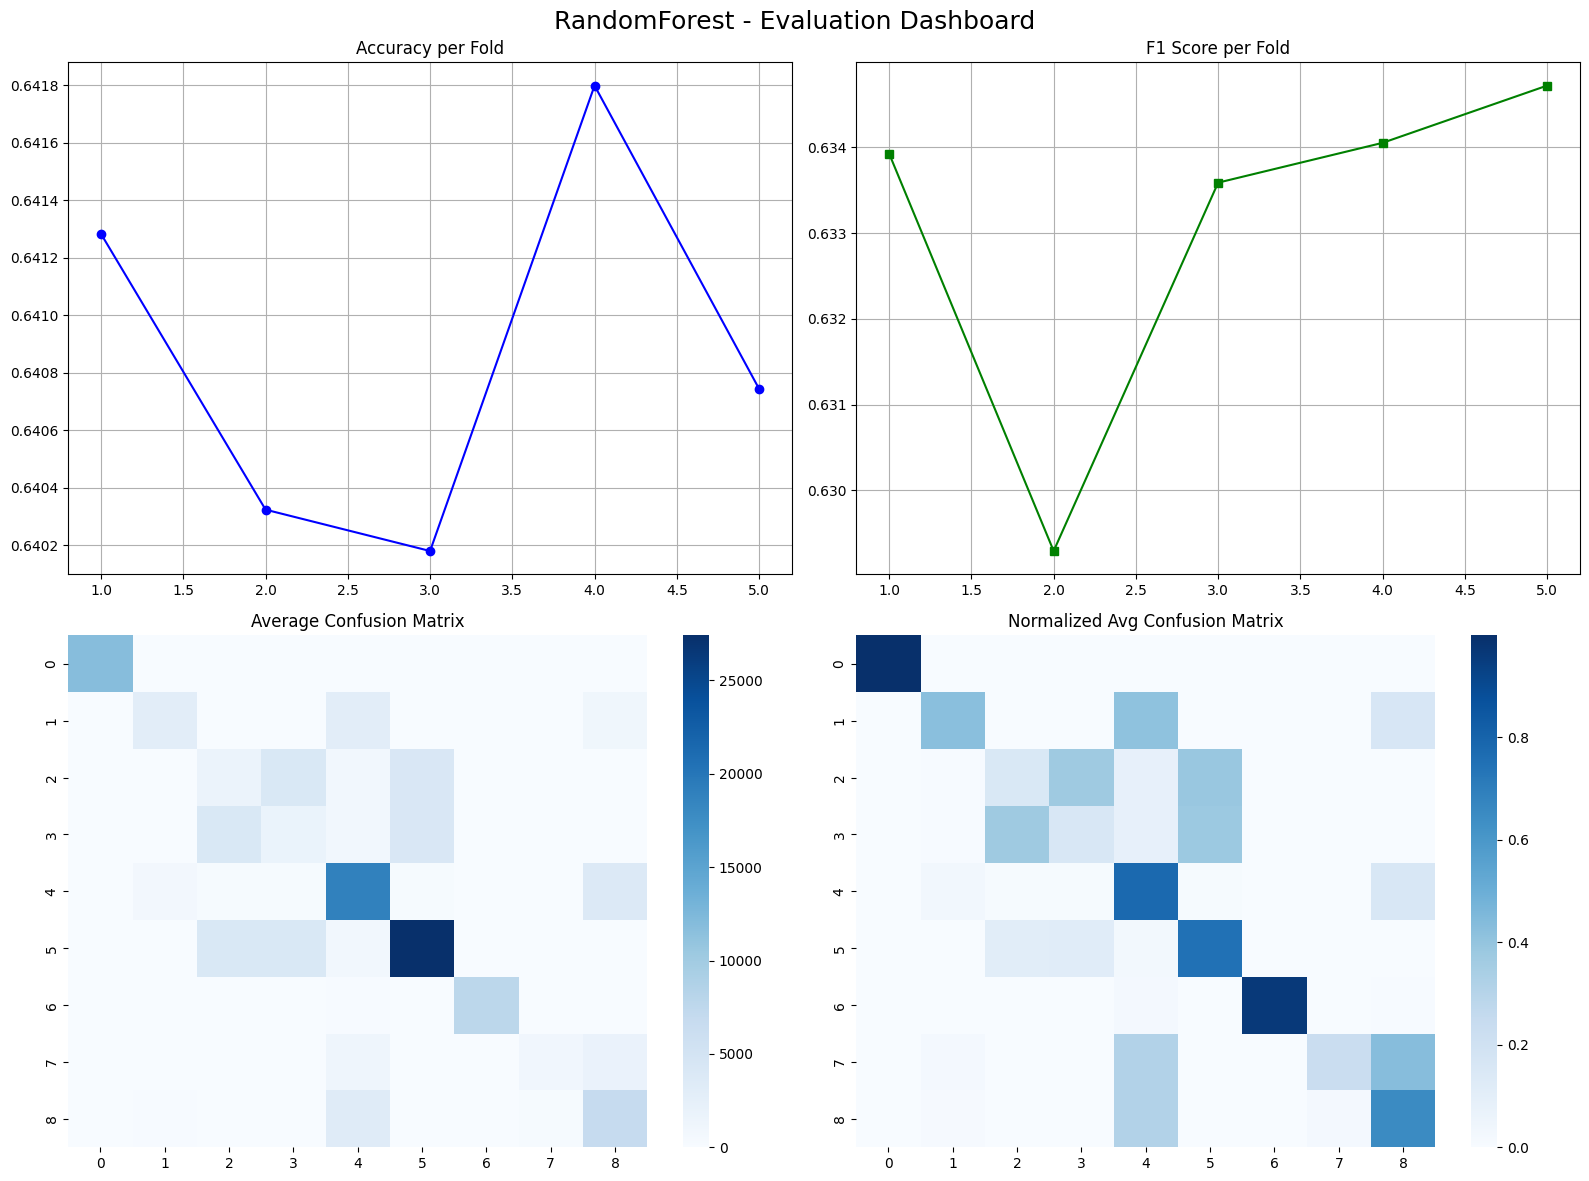

In [12]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ------------------------------------------------------------
# LOAD METRICS JSON
# ------------------------------------------------------------
json_path = r"E:\Thesis\llm-ids-shield\Notebooks\results\rf_best_metrics.json"

with open(json_path, "r") as f:
    metrics_all = json.load(f)

model_name = list(metrics_all.keys())[0]   # auto-detect
folds = metrics_all[model_name]
n_folds = len(folds)

# ------------------------------------------------------------
# EXTRACT METRICS
# ------------------------------------------------------------
accuracy = [fold['accuracy'] for fold in folds]
precision = [fold['precision'] for fold in folds]
recall = [fold['recall'] for fold in folds]
f1_vals = [fold['f1'] for fold in folds]

conf_matrices = [np.array(fold["confusion_matrix"]) for fold in folds]

# ------------------------------------------------------------
# 1️⃣ ACCURACY & F1 SCORE LINE PLOT
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(range(1, n_folds+1), accuracy, marker='o', label='Accuracy')
plt.plot(range(1, n_folds+1), f1_vals, marker='s', label='F1 Score')

plt.title(f"{model_name} (Best Params) - Accuracy & F1 per Fold")
plt.xlabel("Fold")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.grid(True)
plt.xticks(range(1, n_folds+1))
plt.legend()
plt.show()

# ------------------------------------------------------------
# 2️⃣ METRICS SUMMARY TABLE (Pandas)
# ------------------------------------------------------------
summary_df = pd.DataFrame({
    "Fold": list(range(1, n_folds+1)),
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1_vals
})

print("\n===== METRICS SUMMARY TABLE =====")
print(summary_df)
print("\nAVERAGES:")
print(summary_df.mean())

# ------------------------------------------------------------
# 3️⃣ CONFUSION MATRIX PER FOLD (HEATMAP)
# ------------------------------------------------------------
for i, cm in enumerate(conf_matrices, start=1):
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, cmap="Blues", annot=False)
    plt.title(f"{model_name} - Confusion Matrix (Fold {i})")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

# ------------------------------------------------------------
# 4️⃣ NORMALIZED CONFUSION MATRIX (PER FOLD)
# ------------------------------------------------------------
for i, cm in enumerate(conf_matrices, start=1):
    cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

    plt.figure(figsize=(7, 6))
    sns.heatmap(cm_norm, cmap="Blues", annot=False)
    plt.title(f"{model_name} - Normalized Confusion Matrix (Fold {i})")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

# ------------------------------------------------------------
# 5️⃣ AVERAGE CONFUSION MATRIX
# ------------------------------------------------------------
avg_cm = np.mean(conf_matrices, axis=0)

plt.figure(figsize=(8, 7))
sns.heatmap(avg_cm, cmap="Blues", annot=False)
plt.title(f"{model_name} - AVERAGE Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Normalized version
avg_cm_norm = avg_cm / avg_cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(8, 7))
sns.heatmap(avg_cm_norm, cmap="Blues", annot=False)
plt.title(f"{model_name} - AVERAGE Normalized Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# ------------------------------------------------------------
# 6️⃣ FULL DASHBOARD — 1 FIGURE WITH SUBPLOTS
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Accuracy
axes[0, 0].plot(range(1, n_folds+1), accuracy, marker='o', color='blue')
axes[0, 0].set_title("Accuracy per Fold")
axes[0, 0].grid(True)

# F1
axes[0, 1].plot(range(1, n_folds+1), f1_vals, marker='s', color='green')
axes[0, 1].set_title("F1 Score per Fold")
axes[0, 1].grid(True)

# Average Confusion Matrix
sns.heatmap(avg_cm, ax=axes[1, 0], cmap="Blues", annot=False)
axes[1, 0].set_title("Average Confusion Matrix")

# Normalized Average Confusion Matrix
sns.heatmap(avg_cm_norm, ax=axes[1, 1], cmap="Blues", annot=False)
axes[1, 1].set_title("Normalized Avg Confusion Matrix")

plt.suptitle(f"{model_name} - Evaluation Dashboard", fontsize=18)
plt.tight_layout()
plt.show()


In [13]:

import pandas as pd
from sklearn.preprocessing import LabelEncoder

DATA_PATH = "E:\Thesis\llm-ids-shield\Data\Processed\Preprocessed_file.csv"

df = pd.read_csv(DATA_PATH)

# Separate X and y
X = df.drop("Label", axis=1)   # <-- change "label" to your actual label column name
y_raw = df["Label"]

# Encode labels (same as training)
le = LabelEncoder()
y = le.fit_transform(y_raw)

print("Shape of X:", X.shape)
print("Number of classes:", len(le.classes_))


<>:4: SyntaxWarning: invalid escape sequence '\T'
<>:4: SyntaxWarning: invalid escape sequence '\T'
C:\Users\Hp\AppData\Local\Temp\ipykernel_15180\3158835840.py:4: SyntaxWarning: invalid escape sequence '\T'
  DATA_PATH = "E:\Thesis\llm-ids-shield\Data\Processed\Preprocessed_file.csv"


Shape of X: (625783, 22)
Number of classes: 9


In [15]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
import os

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from itertools import cycle

# Paths
RESULTS_DIR = r"E:\Thesis\llm-ids-shield\Notebooks\results"
MODEL_PATH = os.path.join(RESULTS_DIR, "rf_best_model.pkl")
METRICS_PATH = os.path.join(RESULTS_DIR, "rf_best_metrics.json")

# Load model
rf_best = joblib.load(MODEL_PATH)

# Load data (you already know how)
# X, y = ...

# Binarize labels for ROC / PR
y_bin = label_binarize(y, classes=np.unique(y))
n_classes = y_bin.shape[1]


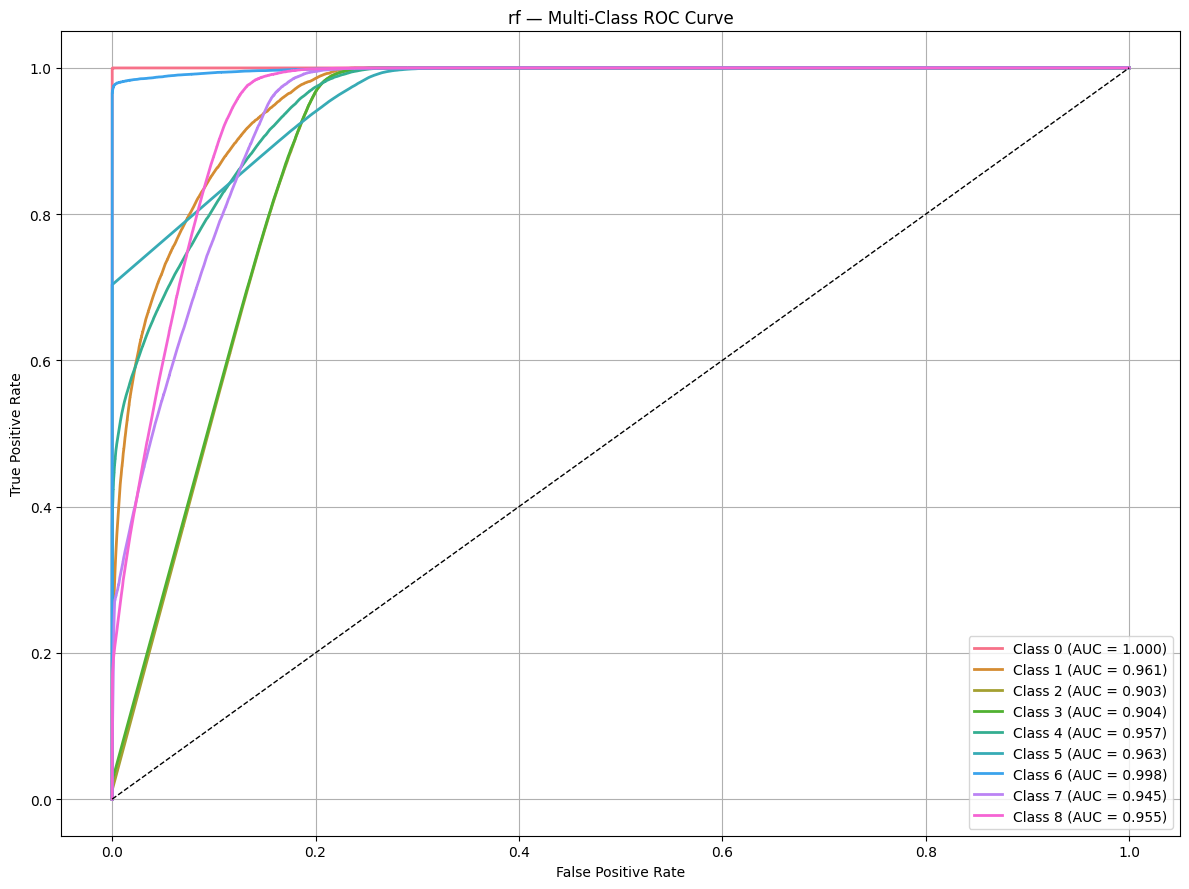

In [16]:
plt.figure(figsize=(12, 9))
y_score = rf_best.predict_proba(X)

colors = cycle(sns.color_palette("husl", n_classes))
for i, color in zip(range(n_classes), colors):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, color=color, label=f"Class {i} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.title("rf — Multi-Class ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(os.path.join(RESULTS_DIR, "rf_roc_curve.png"), dpi=300)
plt.show()


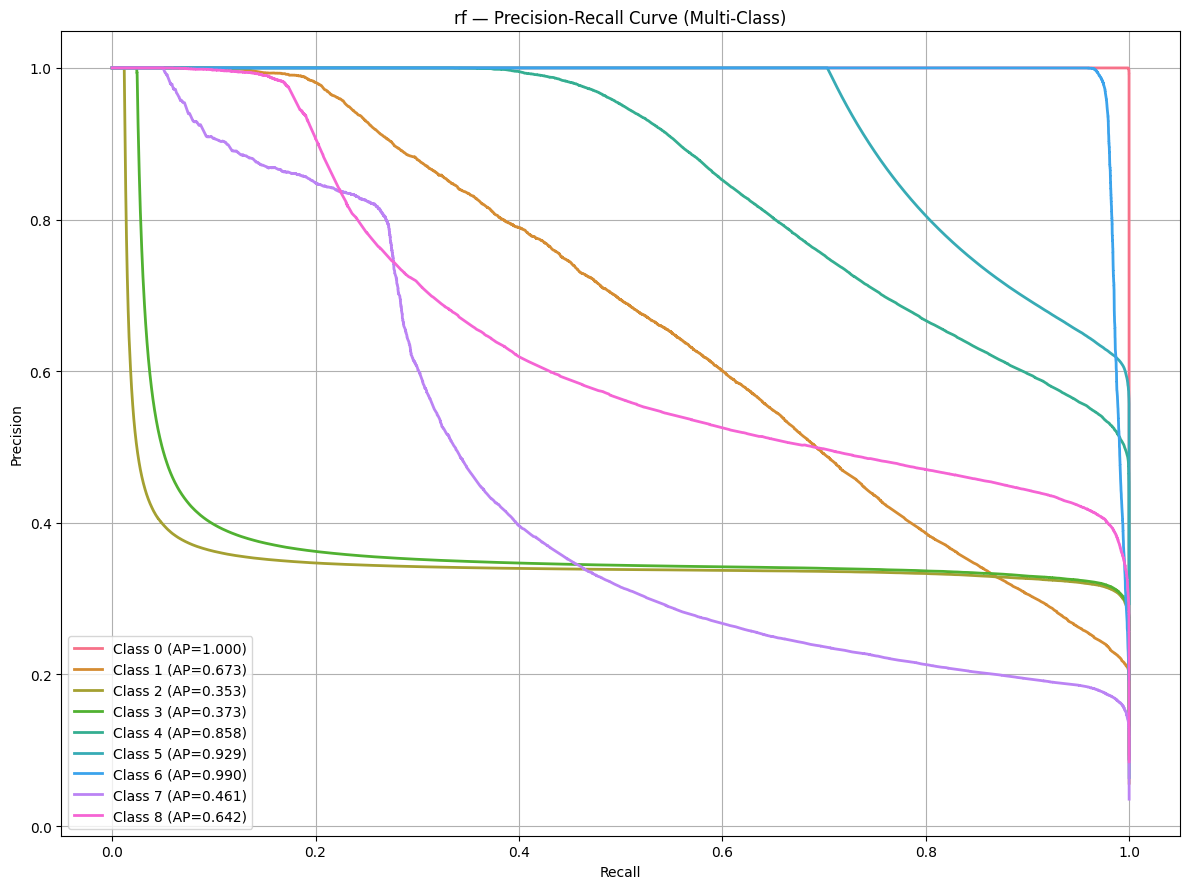

In [17]:
plt.figure(figsize=(12, 9))
colors = cycle(sns.color_palette("husl", n_classes))
y_score = rf_best.predict_proba(X)

for i, color in zip(range(n_classes), colors):
    precision, recall, _ = precision_recall_curve(y_bin[:, i], y_score[:, i])
    ap = average_precision_score(y_bin[:, i], y_score[:, i])
    plt.plot(recall, precision, lw=2, color=color, label=f"Class {i} (AP={ap:.3f})")

plt.title("rf — Precision-Recall Curve (Multi-Class)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(os.path.join(RESULTS_DIR, "rf_precision_recall.png"), dpi=300)
plt.show()
